# 04. Customer Segmentation

Business segmentation on tenure and monthly charges into New/Established/Loyal x Low/High value segments. Deterministic rules, no machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

from src.data_cleaning import load_raw_data, clean_data
from src.segmentation import add_all_features, SEGMENT_ORDER
from src.churn_analysis import churn_by_group
from src.revenue_analysis import revenue_by_group

df = add_all_features(clean_data(load_raw_data())[0])

## Segment definition (documented thresholds)

- **Tenure tier:** New <= 12 months; Established 13-36; Loyal > 36.
- **Value tier:** Low value if MonthlyCharges < $60; High value otherwise.

In [2]:
seg_churn = churn_by_group(df, 'customer_value_segment')
seg_churn = seg_churn.set_index('customer_value_segment').reindex(SEGMENT_ORDER).reset_index()
seg_churn

,customer_value_segment,customers,churned,retained,churn_rate,retention_rate
0,New + Low Value,1133,363,770,0.320388,0.679612
1,New + High Value,1053,674,379,0.640076,0.359924
2,Established + Low Value,795,78,717,0.098113,0.901887
3,Established + High Value,1061,396,665,0.373233,0.626767
4,Loyal + Low Value,979,48,931,0.049030,0.950970
5,Loyal + High Value,2022,310,1712,0.153314,0.846686


In [3]:
seg_rev = revenue_by_group(df, 'customer_value_segment')
seg_rev = seg_rev.set_index('customer_value_segment').reindex(SEGMENT_ORDER).reset_index()
seg_rev.round(2)

,customer_value_segment,customers,churned_customers,total_monthly_revenue,churned_revenue,retained_revenue,churned_revenue_share,churn_rate
0,New + Low Value,1133,363,38013.50,13615.80,24397.70,0.36,0.32
1,New + High Value,1053,674,84616.25,55338.45,29277.80,0.65,0.64
2,Established + Low Value,795,78,26961.45,3287.60,23673.85,0.12,0.10
3,Established + High Value,1061,396,90427.20,34962.00,55465.20,0.39,0.37
4,Loyal + Low Value,979,48,31500.00,2121.15,29378.85,0.07,0.05
5,Loyal + High Value,2022,310,184598.20,29805.85,154792.35,0.16,0.15


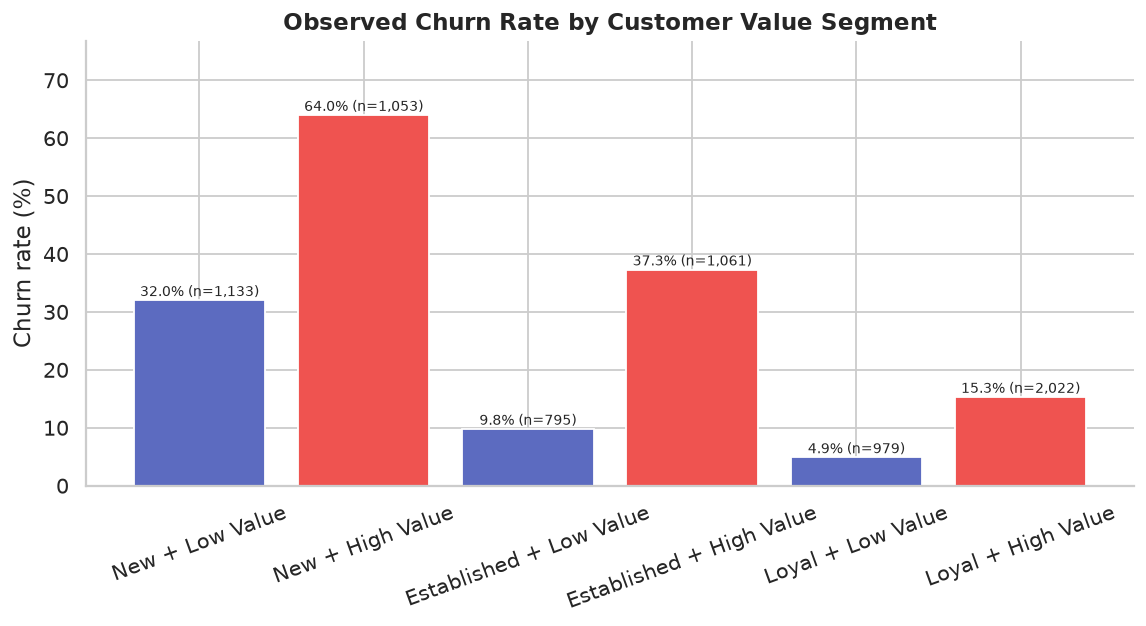

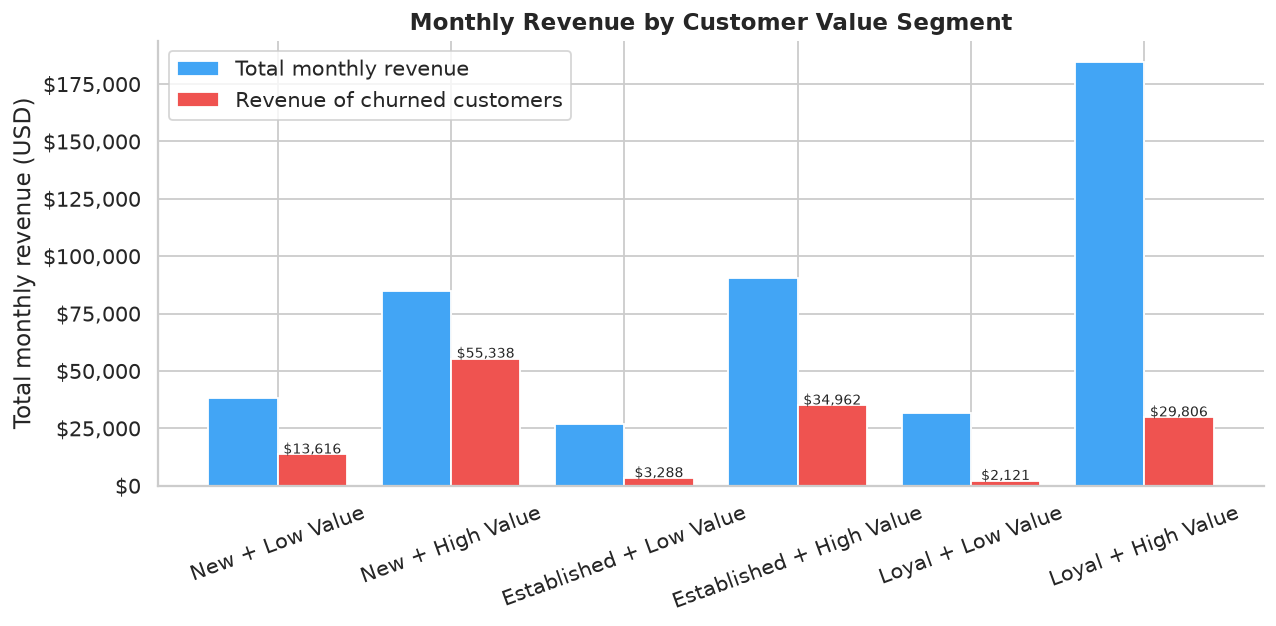

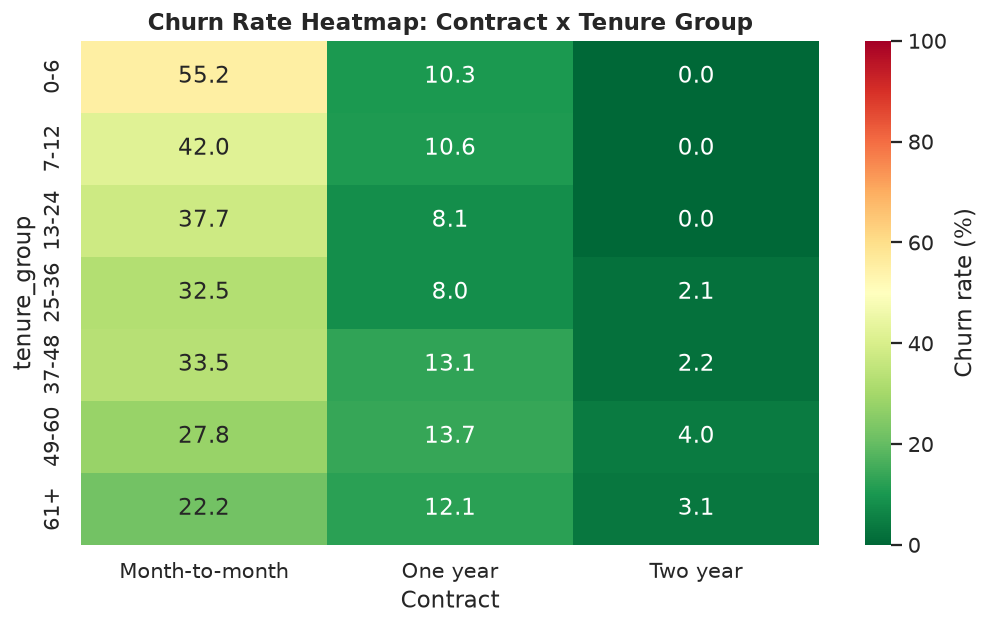

In [4]:
from src.visualization import plot_customer_segmentation, plot_revenue_by_segment, plot_churn_heatmap
plot_customer_segmentation(df)
plot_revenue_by_segment(df)
plot_churn_heatmap(df)
plt.show()

## Interpretation

- **New + High Value** has the highest churn rate (64.0%) and is a large revenue block ($84.6k/mo), making it the top early-intervention target.
- **Loyal + High Value** is the revenue anchor: $184.6k/mo (40% of total monthly revenue) at a 15.3% churn rate.
- The heatmap shows the interaction clearly: month-to-month contracts early in tenure carry churn rates above 60%.